# PART B — PREDICTIVE MODELING

In [1]:
# LIBRARY IMPORTS

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train / Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Classification Evaluation
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    classification_report
)
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Class Imbalance — SMOTE
from imblearn.over_sampling import SMOTE

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Saving / Loading Complete ML Pipeline
import joblib

# Display confirmation
print("All modeling libraries imported successfully.")

All modeling libraries imported successfully.


In [2]:
# STEP 1 — STRATIFIED TRAIN / TEST SPLIT

#load the dataset
df=pd.read_csv("cleaned_titanic.csv")

# Separate features (X) and classification target (y)
X = df.drop(columns=["survived"])
y = df["survived"]

# Perform an 80/20 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the resulting shapes
print("Original dataset shape:", df.shape)

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# Check class distribution before and after splitting
print("\nOriginal class distribution:")
print(y.value_counts(normalize=True).sort_index())

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Original dataset shape: (889, 14)

Training set:
X_train: (711, 13)
y_train: (711,)

Testing set:
X_test: (178, 13)
y_test: (178,)

Original class distribution:
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

Training class distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing class distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


## Stratified Train/Test Split — Interpretation

The cleaned Titanic dataset was divided into 80% training data and 20% testing data using a stratified split with `survived` as the target variable.

The original dataset contains approximately **61.75% non-survivors** and **38.25% survivors**. After splitting, the training set contains approximately **61.74% non-survivors** and **38.26% survivors**, while the testing set contains approximately **61.80% non-survivors** and **38.20% survivors**.

The class proportions remain very similar across the original, training, and testing datasets, showing that stratification successfully preserved the class distribution.

#
#

In [3]:
# STEP 2 — PREPROCESSING

# STEP 2.1 — IDENTIFY NUMERICAL AND CATEGORICAL FEATURES

# Identify categorical columns
categorical_features = ["sex", "embarked"]

# Identify numerical columns
numerical_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

# Display the selected features
print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

print("\nTotal Features Used:", len(categorical_features) + len(numerical_features))

Categorical Features:
['sex', 'embarked']

Numerical Features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Total Features Used: 7


In [4]:
# STEP 2.2 — BUILD PREPROCESSING PIPELINES


# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipelines created successfully.")

Preprocessing pipelines created successfully.


In [5]:
# STEP 2.3 — FIT AND TRANSFORM PREPROCESSOR

# Fit the preprocessor only on training data
preprocessor.fit(X_train)

# Transform training data
X_train_processed = preprocessor.transform(X_train)

# Transform testing data
X_test_processed = preprocessor.transform(X_test)

# Display the processed data shapes
print("Original Training Shape:", X_train.shape)
print("Processed Training Shape:", X_train_processed.shape)

print("\nOriginal Testing Shape:", X_test.shape)
print("Processed Testing Shape:", X_test_processed.shape)

# Confirm preprocessing was applied successfully
print("\nPreprocessing completed successfully.")

Original Training Shape: (711, 13)
Processed Training Shape: (711, 10)

Original Testing Shape: (178, 13)
Processed Testing Shape: (178, 10)

Preprocessing completed successfully.


In [6]:
# STEP 3 — CREATE CLASSIFICATION MODELS

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    random_state=42
)

# Display the models
print("Classification models created successfully.")

print("\nLogistic Regression:")
print(logistic_model)

print("\nDecision Tree:")
print(decision_tree_model)

print("\nRandom Forest:")
print(random_forest_model)

Classification models created successfully.

Logistic Regression:
LogisticRegression(max_iter=1000, random_state=42)

Decision Tree:
DecisionTreeClassifier(random_state=42)

Random Forest:
RandomForestClassifier(random_state=42)


In [7]:
# STEP 3.1 — CREATE COMPLETE CLASSIFICATION PIPELINES

# Create Logistic Regression pipeline
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", logistic_model)
])

# Create Decision Tree pipeline
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", decision_tree_model)
])

# Create Random Forest pipeline
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", random_forest_model)
])

# Display pipeline creation status
print("Classification pipelines created successfully.")

Classification pipelines created successfully.


In [8]:
# STEP 3.2 — TRAIN THE THREE CLASSIFIERS

# Train Logistic Regression
logistic_pipeline.fit(X_train, y_train)

# Train Decision Tree
decision_tree_pipeline.fit(X_train, y_train)

# Train Random Forest
random_forest_pipeline.fit(X_train, y_train)

# Display training status
print("All three classification models trained successfully.")

All three classification models trained successfully.


In [9]:
# STEP 4 — MAKE PREDICTIONS

# Make predictions using Logistic Regression
y_pred_logistic = logistic_pipeline.predict(X_test)

# Make predictions using Decision Tree
y_pred_decision_tree = decision_tree_pipeline.predict(X_test)

# Make predictions using Random Forest
y_pred_random_forest = random_forest_pipeline.predict(X_test)

# Display prediction status
print("Predictions generated successfully.")

print("\nPrediction Shapes:")
print("Logistic Regression:", y_pred_logistic.shape)
print("Decision Tree:", y_pred_decision_tree.shape)
print("Random Forest:", y_pred_random_forest.shape)

Predictions generated successfully.

Prediction Shapes:
Logistic Regression: (178,)
Decision Tree: (178,)
Random Forest: (178,)


In [10]:
# STEP 4.1 — CALCULATE CLASSIFICATION METRICS

# Calculate metrics for Logistic Regression
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

# Calculate metrics for Decision Tree
decision_tree_accuracy = accuracy_score(y_test, y_pred_decision_tree)
decision_tree_precision = precision_score(y_test, y_pred_decision_tree)
decision_tree_recall = recall_score(y_test, y_pred_decision_tree)
decision_tree_f1 = f1_score(y_test, y_pred_decision_tree)

# Calculate metrics for Random Forest
random_forest_accuracy = accuracy_score(y_test, y_pred_random_forest)
random_forest_precision = precision_score(y_test, y_pred_random_forest)
random_forest_recall = recall_score(y_test, y_pred_random_forest)
random_forest_f1 = f1_score(y_test, y_pred_random_forest)

# Display the results
print("Logistic Regression")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

print("\nDecision Tree")
print("Accuracy :", decision_tree_accuracy)
print("Precision:", decision_tree_precision)
print("Recall   :", decision_tree_recall)
print("F1 Score :", decision_tree_f1)

print("\nRandom Forest")
print("Accuracy :", random_forest_accuracy)
print("Precision:", random_forest_precision)
print("Recall   :", random_forest_recall)
print("F1 Score :", random_forest_f1)

Logistic Regression
Accuracy : 0.8089887640449438
Precision: 0.7833333333333333
Recall   : 0.6911764705882353
F1 Score : 0.734375

Decision Tree
Accuracy : 0.7696629213483146
Precision: 0.6901408450704225
Recall   : 0.7205882352941176
F1 Score : 0.7050359712230215

Random Forest
Accuracy : 0.8202247191011236
Precision: 0.78125
Recall   : 0.7352941176470589
F1 Score : 0.7575757575757576


In [11]:
# STEP 4.2 — CONFUSION MATRICES

# Calculate confusion matrices
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
cm_decision_tree = confusion_matrix(y_test, y_pred_decision_tree)
cm_random_forest = confusion_matrix(y_test, y_pred_random_forest)

# Display Logistic Regression confusion matrix
print("Logistic Regression Confusion Matrix:")
print(cm_logistic)

# Display Decision Tree confusion matrix
print("\nDecision Tree Confusion Matrix:")
print(cm_decision_tree)

# Display Random Forest confusion matrix
print("\nRandom Forest Confusion Matrix:")
print(cm_random_forest)

Logistic Regression Confusion Matrix:
[[97 13]
 [21 47]]

Decision Tree Confusion Matrix:
[[88 22]
 [19 49]]

Random Forest Confusion Matrix:
[[96 14]
 [18 50]]


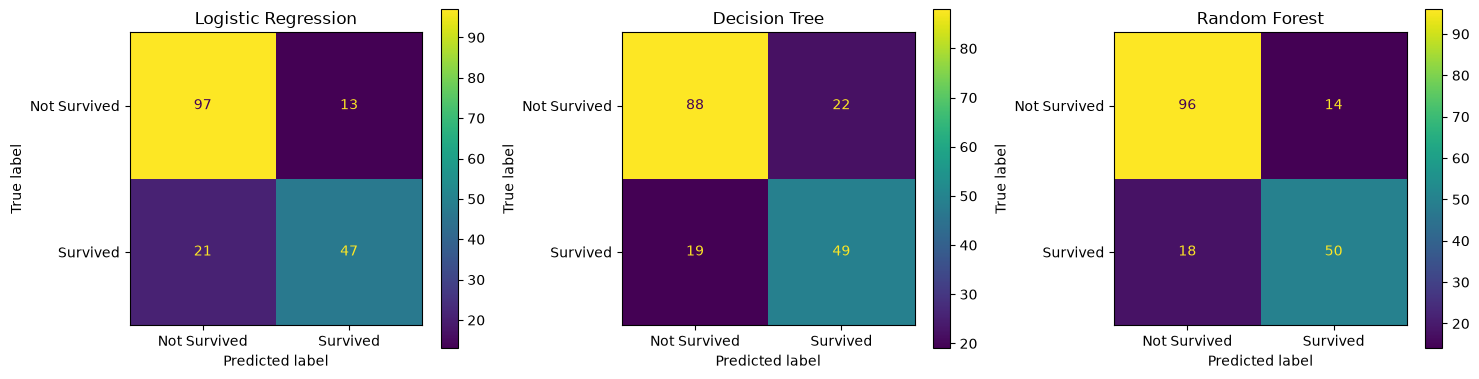

In [12]:
# STEP 4.3 — VISUALIZE CONFUSION MATRICES

# Create figure for all three confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logistic Regression confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Survived", "Survived"]
).plot(ax=axes[0])

axes[0].set_title("Logistic Regression")

# Decision Tree confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_decision_tree,
    display_labels=["Not Survived", "Survived"]
).plot(ax=axes[1])

axes[1].set_title("Decision Tree")

# Random Forest confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_random_forest,
    display_labels=["Not Survived", "Survived"]
).plot(ax=axes[2])

axes[2].set_title("Random Forest")

# Adjust layout
plt.tight_layout()

# Display the plots
plt.show()

In [13]:
# STEP 4.4 — ROC CURVES AND AUC

# Get probability of the positive class (Survived = 1)
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]
y_prob_decision_tree = decision_tree_pipeline.predict_proba(X_test)[:, 1]
y_prob_random_forest = random_forest_pipeline.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_decision_tree, tpr_decision_tree, _ = roc_curve(y_test, y_prob_decision_tree)
fpr_random_forest, tpr_random_forest, _ = roc_curve(y_test, y_prob_random_forest)

# Calculate AUC values
auc_logistic = roc_auc_score(y_test, y_prob_logistic)
auc_decision_tree = roc_auc_score(y_test, y_prob_decision_tree)
auc_random_forest = roc_auc_score(y_test, y_prob_random_forest)

# Display AUC values
print("ROC-AUC Scores:")

print("Logistic Regression:", auc_logistic)
print("Decision Tree      :", auc_decision_tree)
print("Random Forest      :", auc_random_forest)

ROC-AUC Scores:
Logistic Regression: 0.8609625668449199
Decision Tree      : 0.754144385026738
Random Forest      : 0.8179144385026736


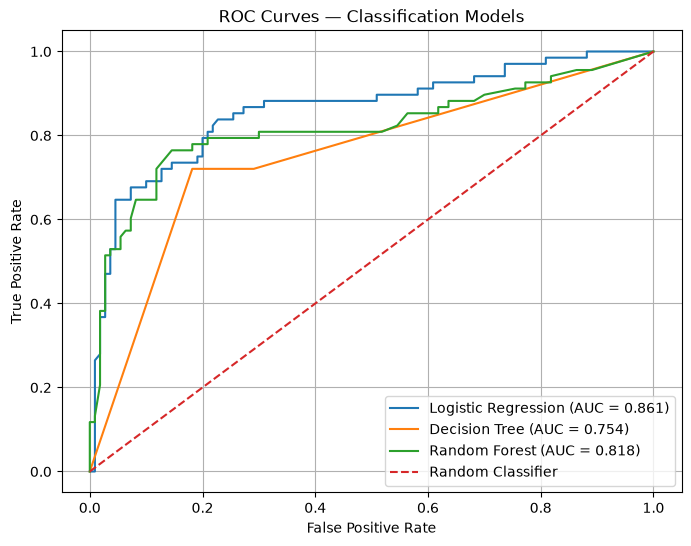

In [14]:
# STEP 4.5 — ROC CURVE VISUALIZATION

# Create ROC curve plot
plt.figure(figsize=(8, 6))

# Plot Logistic Regression ROC curve
plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.3f})"
)

# Plot Decision Tree ROC curve
plt.plot(
    fpr_decision_tree,
    tpr_decision_tree,
    label=f"Decision Tree (AUC = {auc_decision_tree:.3f})"
)

# Plot Random Forest ROC curve
plt.plot(
    fpr_random_forest,
    tpr_random_forest,
    label=f"Random Forest (AUC = {auc_random_forest:.3f})"
)

# Plot random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

# Add plot labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classification Models")

# Display legend
plt.legend()

# Display grid
plt.grid(True)

# Show plot
plt.show()

In [15]:
# STEP 4.6 — CLASSIFICATION MODEL COMPARISON

# Create classification model comparison table
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        decision_tree_precision,
        random_forest_precision
    ],
    "Recall": [
        logistic_recall,
        decision_tree_recall,
        random_forest_recall
    ],
    "F1 Score": [
        logistic_f1,
        decision_tree_f1,
        random_forest_f1
    ],
    "AUC": [
        auc_logistic,
        auc_decision_tree,
        auc_random_forest
    ]
})

# Display the comparison table
classification_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.769663,0.690141,0.720588,0.705036,0.754144
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914


In [16]:
# STEP 5 — CLASS IMBALANCE HANDLING

# STEP 5.1 — REPORT CLASS BALANCE

# Count the number of samples in each class
class_counts = y.value_counts().sort_index()

# Calculate class percentages
class_percentages = y.value_counts(normalize=True).sort_index() * 100

# Display class counts
print("Class Counts:")
print(class_counts)

# Display class percentages
print("\nClass Percentages:")
print(class_percentages)

# Display class balance
print("\nClass Balance:")
print(f"Not Survived (0): {class_counts[0]} ({class_percentages[0]:.2f}%)")
print(f"Survived (1): {class_counts[1]} ({class_percentages[1]:.2f}%)")

Class Counts:
survived
0    549
1    340
Name: count, dtype: int64

Class Percentages:
survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64

Class Balance:
Not Survived (0): 549 (61.75%)
Survived (1): 340 (38.25%)


In [17]:
# STEP 5.2 — BASELINE LOGISTIC REGRESSION

# Create baseline Logistic Regression pipeline
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train baseline model
baseline_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_baseline = baseline_pipeline.predict(X_test)

# Calculate baseline metrics
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

# Display results
print("Baseline Logistic Regression")
print("Precision:", baseline_precision)
print("Recall   :", baseline_recall)
print("F1 Score :", baseline_f1)

Baseline Logistic Regression
Precision: 0.7833333333333333
Recall   : 0.6911764705882353
F1 Score : 0.734375


In [18]:
# STEP 5.3 — LOGISTIC REGRESSION WITH BALANCED CLASS WEIGHTS

# Create Logistic Regression pipeline with balanced class weights
balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train the balanced model
balanced_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_balanced = balanced_pipeline.predict(X_test)

# Calculate metrics
balanced_precision = precision_score(y_test, y_pred_balanced)
balanced_recall = recall_score(y_test, y_pred_balanced)
balanced_f1 = f1_score(y_test, y_pred_balanced)

# Display results
print("Balanced Logistic Regression")
print("Precision:", balanced_precision)
print("Recall   :", balanced_recall)
print("F1 Score :", balanced_f1)

Balanced Logistic Regression
Precision: 0.7183098591549296
Recall   : 0.75
F1 Score : 0.7338129496402878


In [19]:
# STEP 5.4 — SMOTE OVERSAMPLING

# Create a fresh preprocessor for the SMOTE experiment
smote_preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Fit preprocessing only on training data
X_train_processed_smote = smote_preprocessor.fit_transform(X_train)

# Transform testing data using the fitted preprocessor
X_test_processed_smote = smote_preprocessor.transform(X_test)

# Create SMOTE object
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed_smote,
    y_train
)

# Display class distribution before and after SMOTE
print("Training Class Distribution Before SMOTE:")
print(y_train.value_counts())

print("\nTraining Class Distribution After SMOTE:")
print(y_train_smote.value_counts())

# Create Logistic Regression model
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model on SMOTE-resampled training data
smote_model.fit(X_train_smote, y_train_smote)

# Make predictions on the original test data
y_pred_smote = smote_model.predict(X_test_processed_smote)

# Calculate metrics
smote_precision = precision_score(y_test, y_pred_smote)
smote_recall = recall_score(y_test, y_pred_smote)
smote_f1 = f1_score(y_test, y_pred_smote)

# Display results
print("\nSMOTE Logistic Regression")
print("Precision:", smote_precision)
print("Recall   :", smote_recall)
print("F1 Score :", smote_f1)

Training Class Distribution Before SMOTE:
survived
0    439
1    272
Name: count, dtype: int64

Training Class Distribution After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64

SMOTE Logistic Regression
Precision: 0.7352941176470589
Recall   : 0.7352941176470589
F1 Score : 0.7352941176470589


In [20]:
# STEP 5.5 — IMBALANCE HANDLING COMPARISON

# Create comparison table
imbalance_results = pd.DataFrame({
    "Strategy": [
        "Baseline",
        "class_weight='balanced'",
        "SMOTE"
    ],
    "Precision": [
        baseline_precision,
        balanced_precision,
        smote_precision
    ],
    "Recall": [
        baseline_recall,
        balanced_recall,
        smote_recall
    ],
    "F1 Score": [
        baseline_f1,
        balanced_f1,
        smote_f1
    ]
})

# Display the comparison table
imbalance_results

,Strategy,Precision,Recall,F1 Score
0,Baseline,0.783333,0.691176,0.734375
1,class_weight='balanced',0.718310,0.750000,0.733813
2,SMOTE,0.735294,0.735294,0.735294


### Conclusion

The baseline Logistic Regression model achieved a precision of **0.7833**, recall of **0.6912**, and F1-score of **0.7344**.

Using `class_weight="balanced"` increased recall to **0.7500**, but precision decreased to **0.7183**, resulting in an F1-score of **0.7338**.

Using SMOTE increased recall to **0.7353** and produced an F1-score of **0.7353**, with precision of **0.7353**.

Therefore, both class-weight balancing and SMOTE increased recall compared with the baseline, while SMOTE produced the highest F1-score among the three approaches.

## Step 6 — Random Forest Hyperparameter Tuning

GridSearchCV is used to find the best Random Forest hyperparameters using cross-validation.

The parameters tuned are:
- `n_estimators`
- `max_depth`
- `max_features`

Out-of-Bag (OOB) scoring is also used to evaluate the tuned Random Forest using samples not included in each bootstrap sample.

In [21]:
# ============================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

rf_grid = RandomForestClassifier(
    random_state=42,
    oob_score=True
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}

Best Cross-Validation F1 Score:
0.7455711027921034


In [22]:
# ============================================================
# BEST RANDOM FOREST MODEL
# OOB SCORE
# ============================================================

best_rf = grid_search.best_estimator_

print("Best Random Forest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

print("\nOOB Score:")
print(best_rf.oob_score_)

Best Random Forest Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}

Best Cross-Validation F1 Score:
0.7455711027921034

OOB Score:
0.8073136427566807


In [ ]:
# ============================================================
# TUNED RANDOM FOREST — TEST SET EVALUATION
# ============================================================

y_pred_tuned = best_rf.predict(X_test_processed)
y_prob_tuned = best_rf.predict_proba(X_test_processed)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Accuracy: 0.8033707865168539
Precision: 0.7619047619047619
Recall: 0.7058823529411765
F1 Score: 0.732824427480916
ROC-AUC: 0.8236631016042781

Confusion Matrix:
[[95 15]
 [20 48]]


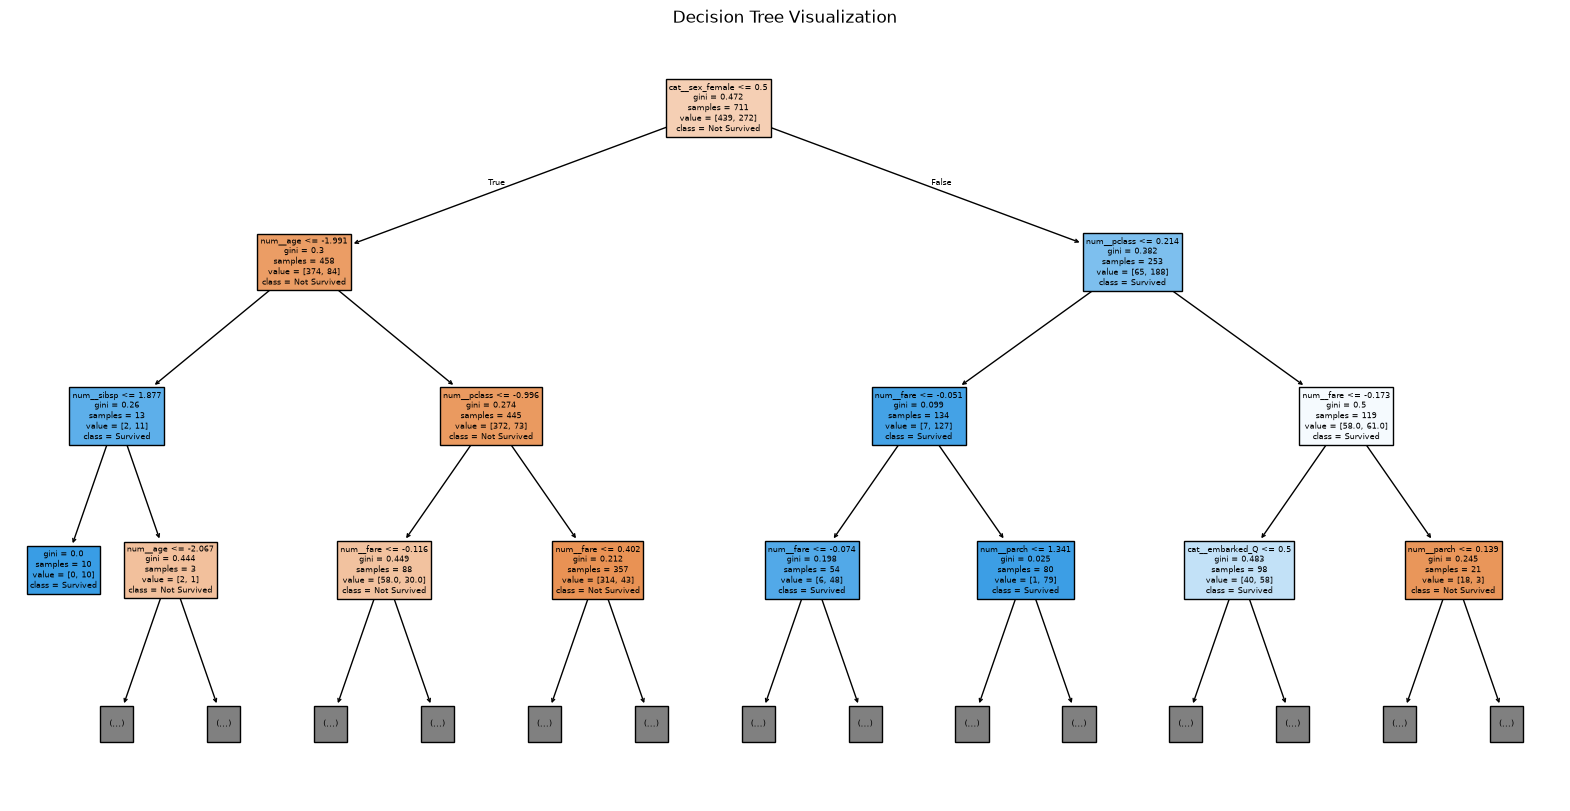

In [ ]:
# ============================================================
# DECISION TREE VISUALIZATION
# ============================================================

feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3
)

plt.title("Decision Tree Visualization")
plt.show()

In [25]:
# FARE REGRESSION — DATA PREPARATION

# Target variable
regression_target = "fare"

# Features
regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = df[regression_features]
y_reg = df[regression_target]

print("Regression features:")
print(regression_features)

print("\nTarget:", regression_target)

print("\nX shape:", X_reg.shape)
print("y shape:", y_reg.shape)

Regression features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked']

Target: fare

X shape: (889, 6)
y shape: (889,)


In [26]:
# FARE REGRESSION — TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_reg_train.shape)
print("Testing data shape:", X_reg_test.shape)
print("Training target shape:", y_reg_train.shape)
print("Testing target shape:", y_reg_test.shape)

Training data shape: (711, 6)
Testing data shape: (178, 6)
Training target shape: (711,)
Testing target shape: (178,)


In [27]:
# FARE REGRESSION — PREPROCESSING

reg_categorical_features = ["sex", "embarked"]

reg_numerical_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer([
    ("num", reg_numerical_pipeline, reg_numerical_features),
    ("cat", reg_categorical_pipeline, reg_categorical_features)
])

print("Regression preprocessing pipeline created successfully.")

Regression preprocessing pipeline created successfully.


In [28]:
# FARE REGRESSION — LINEAR REGRESSION PIPELINE
regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

print("Linear Regression pipeline created successfully.")

Linear Regression pipeline created successfully.


In [29]:
# FARE REGRESSION — MODEL TRAINING

regression_pipeline.fit(X_reg_train, y_reg_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [30]:
# FARE REGRESSION — PREDICTIONS

y_reg_pred = regression_pipeline.predict(X_reg_test)

print("First 10 actual fare values:")
print(y_reg_test.head(10).values)

print("\nFirst 10 predicted fare values:")
print(y_reg_pred[:10])

First 10 actual fare values:
[  7.8542 120.      11.2417  13.      79.65     6.975   13.       8.6625
 110.8833 106.425 ]

First 10 predicted fare values:
[ -2.88475489  95.99511931  27.79356729  29.18366602  89.39234588
  -2.76586876  29.77809669  -2.05255195 100.4411708   84.37654661]


In [31]:
# FARE REGRESSION — MODEL EVALUATION

mae = mean_absolute_error(y_reg_test, y_reg_pred)

rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_reg_pred)
)

r2 = r2_score(y_reg_test, y_reg_pred)

# Number of test samples
n = len(y_reg_test)

# Number of predictors after preprocessing
p = regression_pipeline.named_steps["preprocessor"].transform(
    X_reg_test
).shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)
print("Number of predictors (p):", p)
print("Number of test samples (n):", n)

MAE: 21.138552296883116
RMSE: 41.746502315739114
R²: 0.34677389181134044
Adjusted R²: 0.3117796360155194
Number of predictors (p): 9
Number of test samples (n): 178


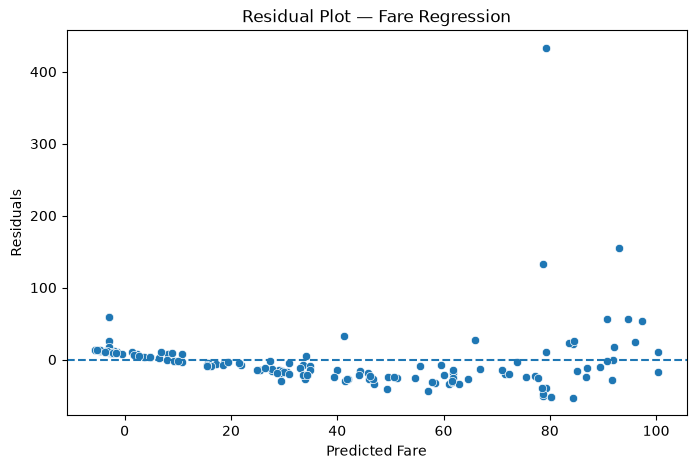

In [32]:
# FARE REGRESSION — RESIDUAL PLOT

residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_reg_pred,
    y=residuals
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot — Fare Regression")

plt.show()

### Residual Plot Interpretation

The residual plot shows evidence of **heteroscedasticity** because the spread of residuals is not constant across the predicted fare values.

At lower predicted fares, the residuals are relatively close to zero, while at higher predicted fares, the residuals show a wider spread and several large deviations.

Therefore, the residuals do not have a constant variance, indicating that the Linear Regression model exhibits heteroscedasticity.

In [33]:
# ============================================================
# FINAL CLASSIFIER COMPARISON
# ============================================================

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

results = []

for model_name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

classifier_comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

print("Final Classifier Comparison:")
display(classifier_comparison.round(4))

Final Classifier Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7697,0.6901,0.7206,0.7050,0.7541
2,Random Forest,0.8202,0.7812,0.7353,0.7576,0.8179


In [34]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

# Copy the classifier results
final_classifiers = classifier_comparison.copy()

# Add regression results as a separate row
regression_row = pd.DataFrame({
    "Model": ["Fare Regression"],
    "Accuracy": [np.nan],
    "Precision": [np.nan],
    "Recall": [np.nan],
    "F1 Score": [np.nan],
    "ROC-AUC": [np.nan]
})

final_classifiers = pd.concat(
    [final_classifiers, regression_row],
    ignore_index=True
)

# Add model type
final_classifiers.insert(
    1,
    "Model Type",
    ["Classification", "Classification", "Classification", "Regression"]
)

# Add regression metrics
final_classifiers["MAE"] = [np.nan, np.nan, np.nan, mae]
final_classifiers["RMSE"] = [np.nan, np.nan, np.nan, rmse]
final_classifiers["R²"] = [np.nan, np.nan, np.nan, r2]
final_classifiers["Adjusted R²"] = [
    np.nan, np.nan, np.nan, adjusted_r2
]

display(final_classifiers.round(4))

,Model,Model Type,Accuracy,Precision,Recall,F1 Score,ROC-AUC,MAE,RMSE,R²,Adjusted R²
0,Logistic Regression,Classification,0.8090,0.7833,0.6912,0.7344,0.8610,NaN,NaN,NaN,NaN
1,Decision Tree,Classification,0.7697,0.6901,0.7206,0.7050,0.7541,NaN,NaN,NaN,NaN
2,Random Forest,Classification,0.8202,0.7812,0.7353,0.7576,0.8179,NaN,NaN,NaN,NaN
3,Fare Regression,Regression,NaN,NaN,NaN,NaN,NaN,21.1386,41.7465,0.3468,0.3118


## Final Model Recommendation

Among the three classification models, the Random Forest achieved the highest accuracy of **0.8202** and the highest F1-score of **0.7576**, while Logistic Regression achieved the highest ROC-AUC of **0.8610**.

The Decision Tree achieved an accuracy of **0.7697**, F1-score of **0.7050**, and ROC-AUC of **0.7541**, which were lower than the corresponding values of the other two classifiers.

For the fare regression task, the Linear Regression model achieved an MAE of **21.1386**, RMSE of **41.7465**, R² of **0.3468**, and Adjusted R² of **0.3118**, indicating that the selected features explain a limited portion of fare variation.

Based on the classification metrics, Random Forest provides the strongest overall classification performance by accuracy and F1-score, while Logistic Regression provides the highest ROC-AUC.

In [35]:
# FINAL TUNED RANDOM FOREST PIPELINE

best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        max_features="sqrt",
        random_state=42,
        oob_score=True
    ))
])

# Train the final pipeline
best_pipeline.fit(X_train, y_train)

print("Final tuned Random Forest pipeline trained successfully.")

Final tuned Random Forest pipeline trained successfully.


In [36]:
# SAVE AND RELOAD BEST PIPELINE

pipeline_path = "best_titanic_pipeline.joblib"

# Save the complete pipeline
joblib.dump(best_pipeline, pipeline_path)

print("Pipeline saved successfully.")

# Reload the pipeline
loaded_pipeline = joblib.load(pipeline_path)

print("Pipeline loaded successfully.")

Pipeline saved successfully.
Pipeline loaded successfully.


In [37]:
# TEST SAVED PIPELINE WITH RAW INPUT]

raw_input = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(raw_input)

print("Raw input:")
display(raw_input)

print("\nPrediction:", prediction[0])

if prediction[0] == 1:
    print("Result: Survived")
else:
    print("Result: Not Survived")

Raw input:


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
159,3,male,44.0,0,1,16.1,S,Third,man,True,Southampton,no,False



Prediction: 0
Result: Not Survived
